In [6]:
import sys
sys.path.append("..")
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.svi as svi
import src.heston as heston
import src.config as config
import src.black_scholes as bs
from src.implied_vol import implied_vol
importlib.reload(heston)

date = config.SNAPSHOT_DATE
svi_params = pd.read_csv(f"../data/svi_params_{date}.csv", parse_dates=["expiry"])
smiles = pd.read_csv(f"../data/spy_smiles_{date}.csv", parse_dates=["expiry"])
market = pd.read_csv(f"../data/spy_market_{date}.csv", index_col=0).iloc[:, 0]
r, S0 = float(market["r"]), float(market["spot"])
F_by_expiry = smiles.groupby("expiry")["F"].first()

print(f"S0 = {S0:.2f} | r = {r:.2%} | {len(svi_params)} maturités SVI")

S0 = 779.88 | r = 4.03% | 26 maturités SVI


In [7]:
F_t, r_t, T_t = 100.0, 0.05, 1.0
K_t = np.array([80.0, 90.0, 100.0, 110.0, 120.0])

h = heston.heston_call(F_t, K_t, T_t, r_t, v0=0.04, kappa=2.0, theta=0.04, xi=0.01, rho=0.0)
b = bs.bs_price(F_t, K_t, T_t, r_t, 0.2, "call", q=r_t)

for K_, hh, bb in zip(K_t, h, b):
    print(f"K = {K_:.0f} | Heston (ξ ≈ 0) = {hh:.4f} | Black-Scholes = {bb:.4f} | écart = {abs(hh - bb):.1e}")

K = 80 | Heston (ξ ≈ 0) = 20.1527 | Black-Scholes = 20.1527 | écart = 2.5e-05
K = 90 | Heston (ξ ≈ 0) = 12.9262 | Black-Scholes = 12.9264 | écart = 1.4e-04
K = 100 | Heston (ξ ≈ 0) = 7.5769 | Black-Scholes = 7.5771 | écart = 2.3e-04
K = 110 | Heston (ξ ≈ 0) = 4.0825 | Black-Scholes = 4.0827 | écart = 1.6e-04
K = 120 | Heston (ξ ≈ 0) = 2.0425 | Black-Scholes = 2.0426 | écart = 2.9e-05


In [10]:
pd.Series({"v0": v0, "kappa": kappa, "theta": theta, "xi": xi, "rho": rho}).to_csv(
    f"../data/heston_params_{date}.csv")
print("Paramètres Heston sauvegardés")

Paramètres Heston sauvegardés


In [8]:
import time

rows = []
for _, row in svi_params.iterrows():
    T = row["T"]
    if T < 30 / 365:
        continue
    p = row[["a", "b", "rho", "m", "sigma"]].values.astype(float)
    F = F_by_expiry[row["expiry"]]
    atm = svi.svi_implied_vol(0.0, T, p)
    k = np.linspace(-2.5, 1.5, 13) * atm * np.sqrt(T)   # grille adaptée à la maturité
    for kj, ivj in zip(k, svi.svi_implied_vol(k, T, p)):
        rows.append({"expiry": row["expiry"], "T": T, "F": F, "k": kj, "K": F * np.exp(kj), "iv": ivj})
calib = pd.DataFrame(rows)
print(f"{len(calib)} points de calibration sur {calib['expiry'].nunique()} maturités")

t0 = time.perf_counter()
params, res = heston.calibrate_heston(calib["F"], calib["K"], calib["T"], r, calib["iv"])
v0, kappa, theta, xi, rho = params

print(f"\nCalibration terminée en {time.perf_counter() - t0:.1f} s")
print(f"v0 = {v0:.4f}  (vol actuelle ≈ {np.sqrt(v0):.1%})")
print(f"θ  = {theta:.4f}  (vol long terme ≈ {np.sqrt(theta):.1%})")
print(f"κ  = {kappa:.3f}  (demi-vie du retour à la moyenne ≈ {np.log(2) / kappa:.2f} an)")
print(f"ξ  = {xi:.3f}")
print(f"ρ  = {rho:.3f}")
print(f"RMSE ≈ {np.sqrt(np.mean(res.fun ** 2)) * 100:.2f} points de vol")
print(f"Condition de Feller : 2κθ = {2 * kappa * theta:.4f}  vs  ξ² = {xi ** 2:.4f}  →  "
      f"{'respectée' if 2 * kappa * theta > xi ** 2 else 'violée'}")

260 points de calibration sur 20 maturités

Calibration terminée en 3.0 s
v0 = 0.0174  (vol actuelle ≈ 13.2%)
θ  = 0.0593  (vol long terme ≈ 24.3%)
κ  = 1.897  (demi-vie du retour à la moyenne ≈ 0.37 an)
ξ  = 0.874
ρ  = -0.643
RMSE ≈ 0.44 points de vol
Condition de Feller : 2κθ = 0.2249  vs  ξ² = 0.7641  →  violée


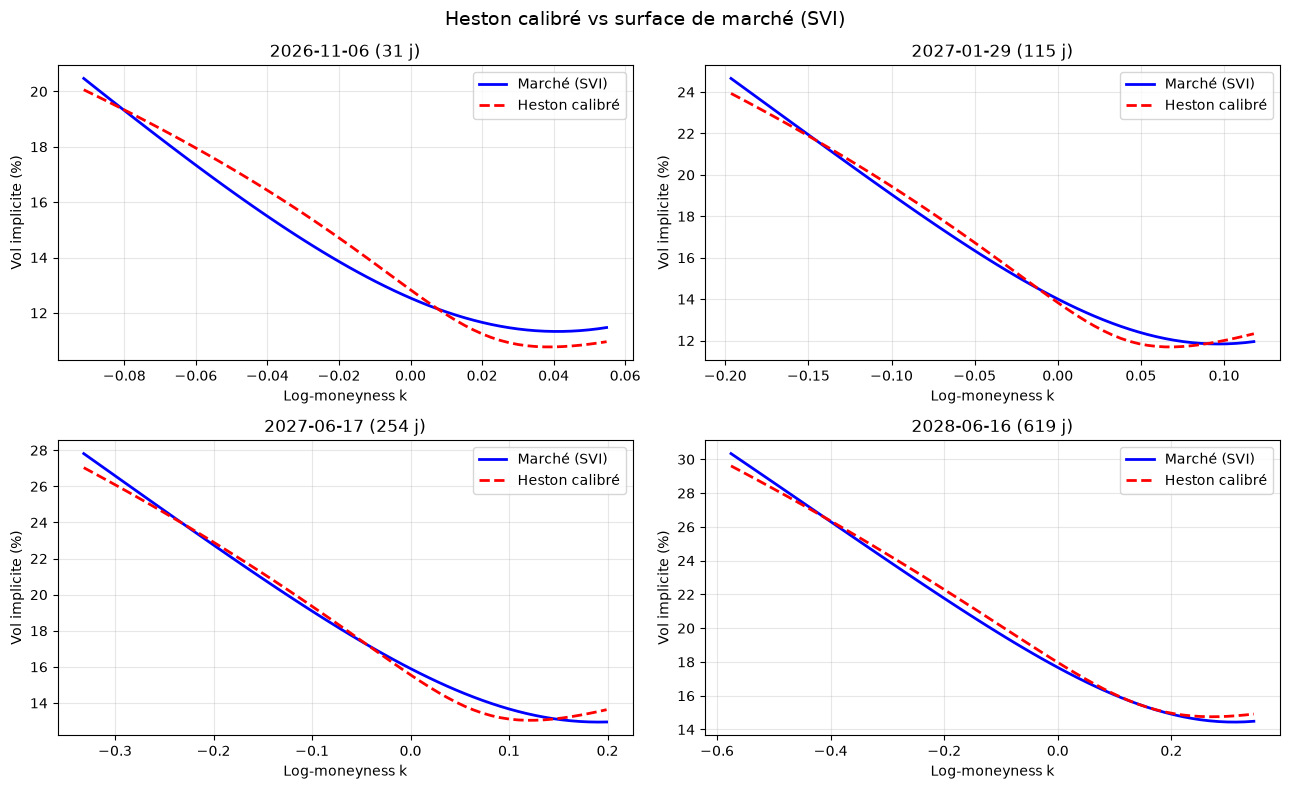

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, days in zip(axes.flat, [30, 115, 254, 600]):
    exp = calib.loc[(calib["T"] - days / 365).abs().idxmin(), "expiry"]
    c = calib[calib["expiry"] == exp]
    T, F = c["T"].iloc[0], c["F"].iloc[0]
    k_fine = np.linspace(c["k"].min(), c["k"].max(), 60)

    prices = heston.heston_call(F, F * np.exp(k_fine), T, r, *params)
    iv_heston = [implied_vol(pr, F, F * np.exp(kk), T, r, "call", q=r) for pr, kk in zip(prices, k_fine)]
    p_svi = svi_params.loc[svi_params["expiry"] == exp, ["a", "b", "rho", "m", "sigma"]].values[0].astype(float)

    ax.plot(k_fine, svi.svi_implied_vol(k_fine, T, p_svi) * 100, "b-", lw=2, label="Marché (SVI)")
    ax.plot(k_fine, np.array(iv_heston) * 100, "r--", lw=2, label="Heston calibré")
    ax.set_title(f"{pd.Timestamp(exp).date()} ({T * 365:.0f} j)")
    ax.set_xlabel("Log-moneyness k")
    ax.set_ylabel("Vol implicite (%)")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Heston calibré vs surface de marché (SVI)", fontsize=14)
fig.tight_layout()
fig.savefig("../figures/heston_fit.png", dpi=150, bbox_inches="tight")
plt.show()